In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadwaqas023/islamic-pilgrimage-dataset-2000-2026/Islamic_Pilgrimage_2000_2026_Dataset.csv


____Loading file and importing modules____

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/kaggle/input/datasets/muhammadwaqas023/islamic-pilgrimage-dataset-2000-2026/Islamic_Pilgrimage_2000_2026_Dataset.csv")

**some basic infos and duplicate checks**

In [4]:
df.head()

,Year,Country,Pilgrimage_Type,Total_Pilgrims,Male_Percentage,Female_Percentage,Average_Age,Average_Travel_Cost_USD,Visa_Approval_Rate,Flights_Arranged,Hotels_Booked,Satisfaction_Rating,Economic_Impact_USD
0,2000,Pakistan,Hajj,126958,60.93,39.07,33.5,9686.76,87.31,141,224,3.12,1.680139e+09
1,2000,Pakistan,Umrah,180203,47.86,52.14,47.5,2092.32,90.94,433,201,4.98,4.213378e+08
2,2000,Pakistan,Ziyarat,352449,55.50,44.50,41.0,4557.91,87.74,189,197,3.73,1.535860e+09
3,2000,Saudi Arabia,Hajj,89654,57.37,42.63,39.5,11823.92,83.54,326,144,3.34,5.989896e+08
4,2000,Saudi Arabia,Umrah,146699,63.84,36.16,44.9,5546.87,70.46,405,101,3.88,5.061651e+08


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4455 entries, 0 to 4454
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     4455 non-null   int64  
 1   Country                  4455 non-null   object 
 2   Pilgrimage_Type          4455 non-null   object 
 3   Total_Pilgrims           4455 non-null   int64  
 4   Male_Percentage          4455 non-null   float64
 5   Female_Percentage        4455 non-null   float64
 6   Average_Age              4455 non-null   float64
 7   Average_Travel_Cost_USD  4455 non-null   float64
 8   Visa_Approval_Rate       4455 non-null   float64
 9   Flights_Arranged         4455 non-null   int64  
 10  Hotels_Booked            4455 non-null   int64  
 11  Satisfaction_Rating      4455 non-null   float64
 12  Economic_Impact_USD      4455 non-null   float64
dtypes: float64(7), int64(4), object(2)
memory usage: 452.6+ KB


In [6]:
df.columns=df.columns.str.lower()
df.duplicated().sum()

np.int64(0)

In [7]:
df['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026])

In [8]:
df['country'].nunique()

55

**statical analysis of dataset**

In [9]:
df.describe()

,year,total_pilgrims,male_percentage,female_percentage,average_age,average_travel_cost_usd,visa_approval_rate,flights_arranged,hotels_booked,satisfaction_rating,economic_impact_usd
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4.455000e+03
mean,2013.000000,253826.037935,55.002808,44.997192,42.881122,6715.833962,84.446303,258.980471,154.014590,4.017302,1.702726e+09
std,7.789755,142084.278821,5.730716,5.730716,8.618866,3001.942867,8.437909,137.743743,84.277654,0.579470,1.431296e+09
min,2000.000000,5005.000000,45.000000,35.000000,28.000000,1500.320000,70.000000,20.000000,10.000000,3.000000,5.720176e+06
25%,2006.000000,132056.500000,50.155000,40.120000,35.500000,4173.830000,77.160000,140.000000,80.000000,3.530000,6.080341e+08
50%,2013.000000,256987.000000,55.060000,44.940000,43.000000,6704.890000,84.280000,261.000000,153.000000,4.030000,1.319453e+09
75%,2020.000000,376683.000000,59.880000,49.845000,50.100000,9293.800000,91.860000,378.000000,228.000000,4.510000,2.416015e+09
max,2026.000000,499925.000000,65.000000,55.000000,58.000000,11998.870000,99.000000,499.000000,299.000000,5.000000,8.342094e+09


In [10]:
year_wise_top=df.loc[df.groupby(['year','country'])['total_pilgrims'].idxmin(),['year','country','pilgrimage_type','total_pilgrims']].sort_values('total_pilgrims',ascending=False)
year_wise_top.head(10),year_wise_top.tail(10)

(      year       country pilgrimage_type  total_pilgrims
 3140  2019  Saudi Arabia         Ziyarat          446049
 3575  2021  South Africa         Ziyarat          430389
 1702  2010       Algeria           Umrah          420313
 3435  2020    Kazakhstan            Hajj          419536
 3330  2020          Iraq            Hajj          415412
 184   2001    Bangladesh           Umrah          415303
 4012  2024       Algeria           Umrah          407592
 4422  2026    Uzbekistan            Hajj          398922
 3494  2021          Iran         Ziyarat          398733
 155   2000       Denmark         Ziyarat          395530,
       year        country pilgrimage_type  total_pilgrims
 2377  2014          Yemen           Umrah            6511
 1204  2007        Morocco           Umrah            6379
 71    2000  United States         Ziyarat            6252
 1425  2008         Brazil            Hajj            5987
 989   2005        Austria         Ziyarat            5799
 757   

**Analysis on basis of years**

Text(0.5, 1.0, 'top ten lowest no of pilgrims')

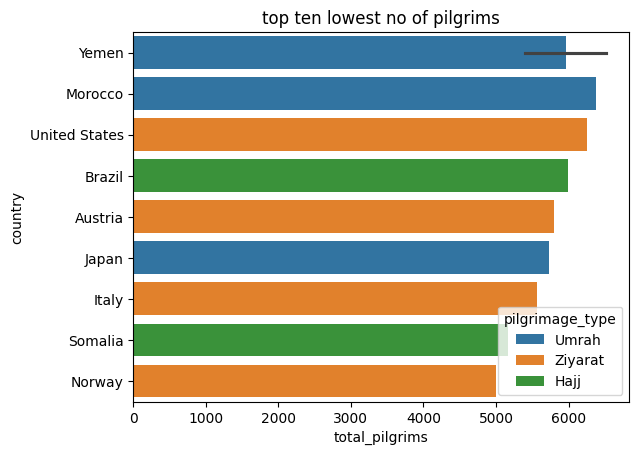

In [11]:

sns.barplot(x='total_pilgrims',y='country',data=year_wise_top.tail(10),hue='pilgrimage_type')
plt.title("top ten lowest no of pilgrims")

<Axes: xlabel='pilgrimage_type', ylabel='total_pilgrims'>

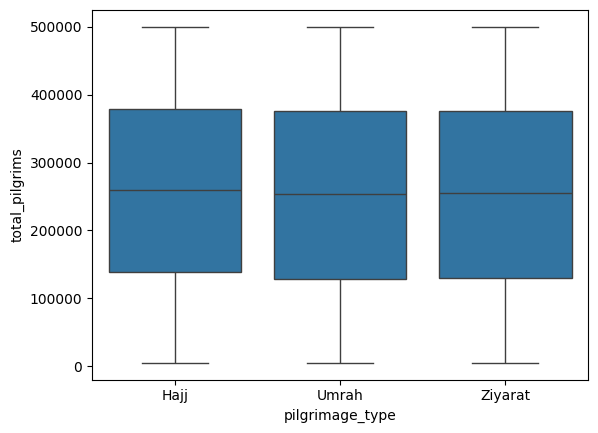

In [12]:
pilgrimage_count=df.groupby('pilgrimage_type')['total_pilgrims']
sns.boxplot(
    data=df,
    x='pilgrimage_type',
    y='total_pilgrims'
)

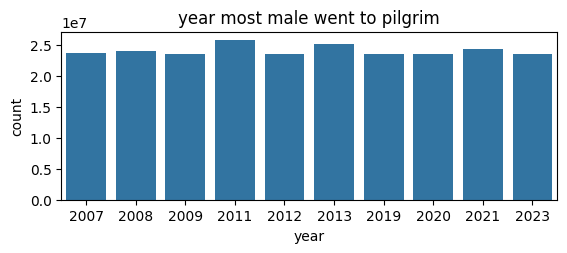

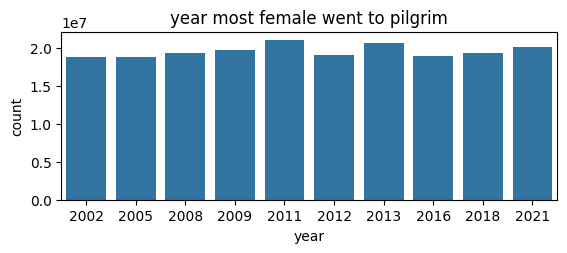

In [13]:
df['count_male']=df['total_pilgrims']*(df['male_percentage']/100)
df['count_female']=df['total_pilgrims']*(df['female_percentage']/100)
group=df.groupby('year')['count_male'].sum().sort_values(ascending=False).head(10)
group2=df.groupby('year')['count_female'].sum().sort_values(ascending=False).head(10)
plt.subplot(2,1,1)
sns.barplot(x=group.index,y=group.values)
plt.title("year most male went to pilgrim")
plt.ylabel("count")
plt.show()
plt.subplot(2,1,2)
sns.barplot(x=group2.index,y=group2.values)
plt.title("year most female went to pilgrim")
plt.ylabel("count")
plt.show()

Text(0.5, 0, 'year')

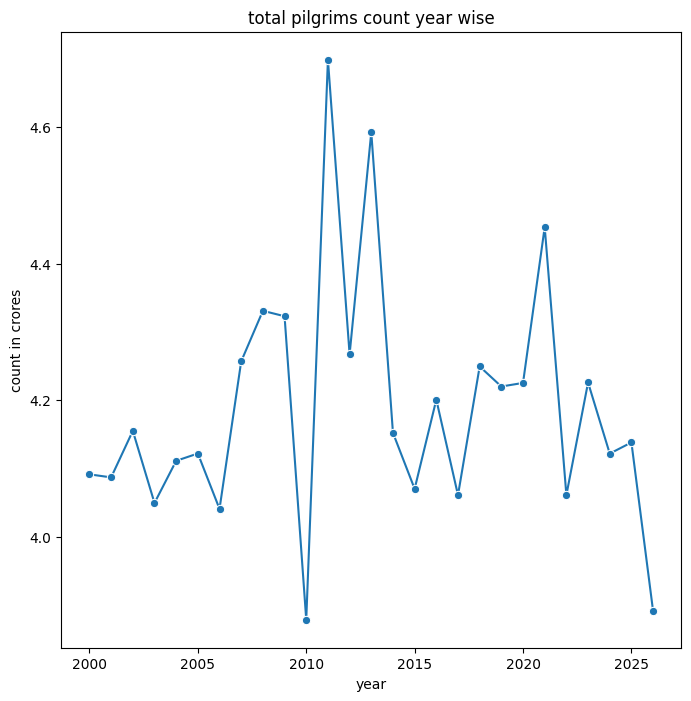

In [14]:
year_wise_pilgrims=df.groupby('year')['total_pilgrims'].sum()
plt.figure(figsize=(8,8))
sns.lineplot(x=year_wise_pilgrims.index,y=year_wise_pilgrims.values/10000000,marker="o")
plt.title("total pilgrims count year wise")
plt.ylabel("count in crores")
plt.xlabel("year")

Text(0.5, 1.0, 'no of hotels book year_wise')

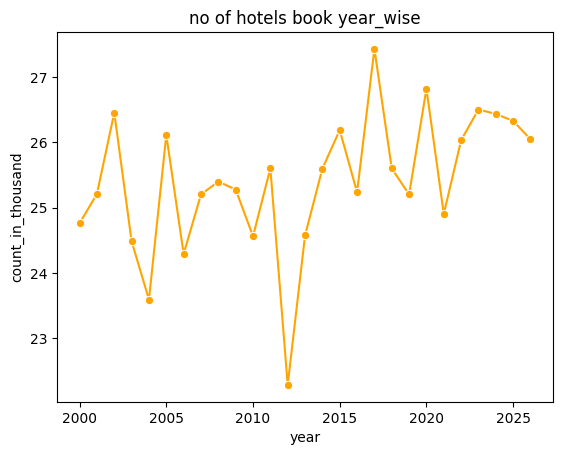

In [15]:
year_wise_hotel_books=df.groupby('year')['hotels_booked'].sum()
sns.lineplot(x=year_wise_hotel_books.index,y=year_wise_hotel_books.values/1000,color="orange",marker="o")
plt.ylabel("count_in_thousand")
plt.title("no of hotels book year_wise")


Text(0, 0.5, 'flight count (thousand)')

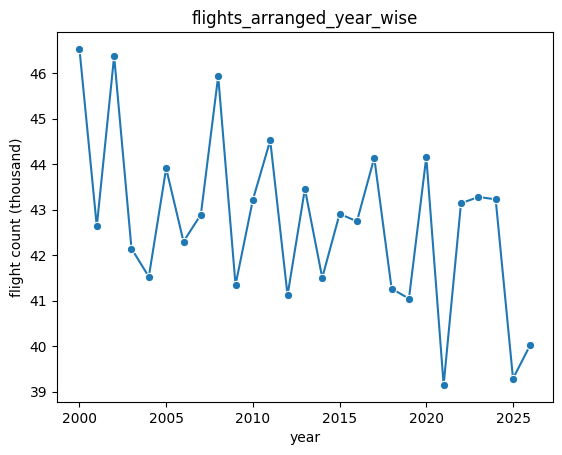

In [16]:
flights_arranged_year_wise=df.groupby('year')['flights_arranged'].sum()
sns.lineplot(x=flights_arranged_year_wise.index,y=flights_arranged_year_wise.values/1000,marker="o")
plt.title("flights_arranged_year_wise")
plt.ylabel("flight count (thousand)")


<Axes: title={'center': 'average age of pilgrims year wise'}, xlabel='year', ylabel='age of pilgrims'>

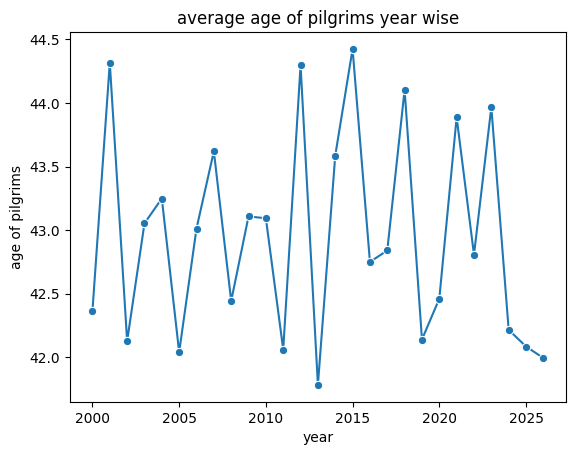

In [17]:
avg_age_year_wise = (
    (df['average_age'] * df['total_pilgrims'])
    .groupby(df['year'])
    .sum()
    / df.groupby('year')['total_pilgrims'].sum()
)
plt.title("average age of pilgrims year wise")
plt.ylabel("age of pilgrims")
sns.lineplot(x=avg_age_year_wise.index,y=avg_age_year_wise.values,marker="o")

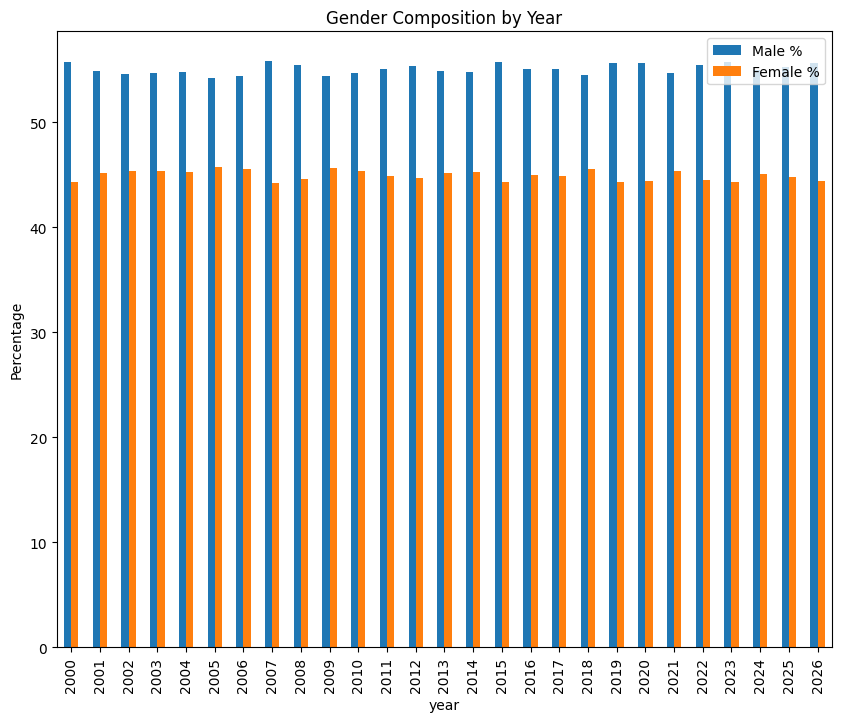

In [18]:
# total male percentage vs total female percentage year_wise
male_count_percentage=(df.groupby('year')['count_male'].sum()/((df.groupby('year')['count_male'].sum()+df.groupby('year')['count_female'].sum())))*100
female_count_percentage=100-male_count_percentage
gender_percentage = pd.DataFrame({
    'Male %': male_count_percentage,
    'Female %': female_count_percentage
})

gender_percentage.plot(
    kind='bar',
    stacked=False,
    figsize=(10,8)
)

plt.ylabel('Percentage')
plt.title('Gender Composition by Year')
plt.show()

Text(0, 0.5, 'USD (100 Billions)')

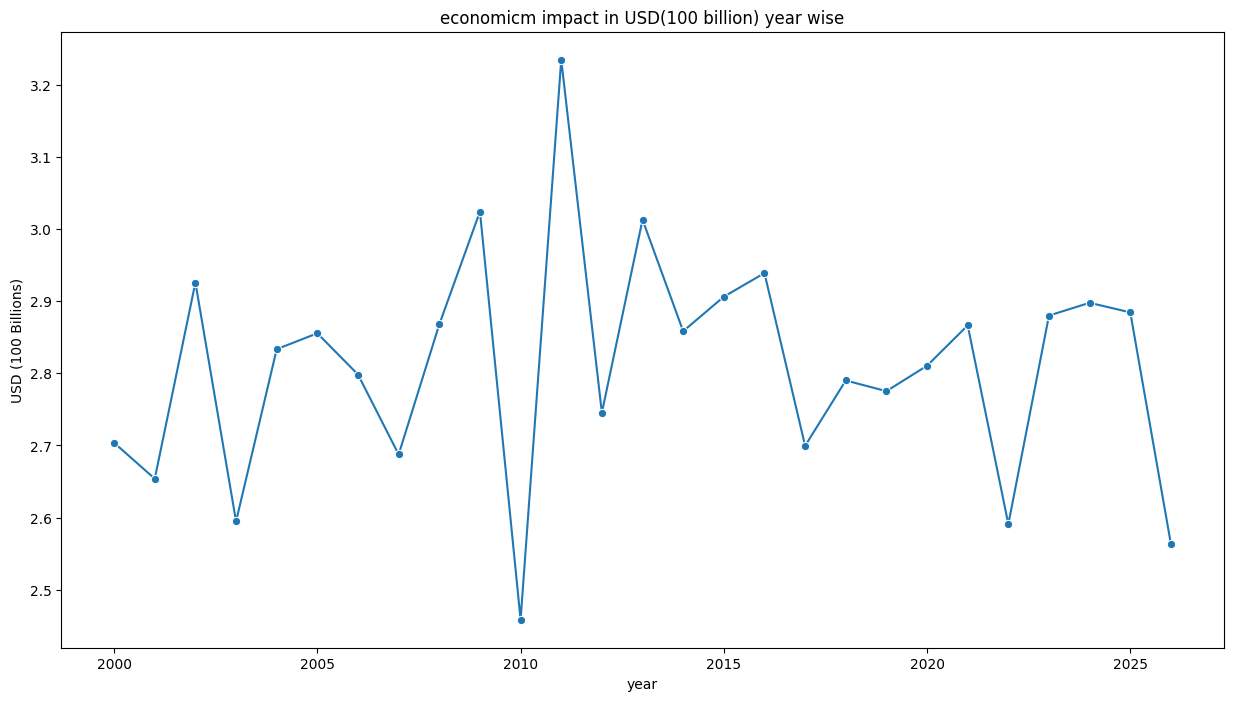

In [19]:
economic_impact_year_wise=df.groupby('year')['economic_impact_usd'].sum()
plt.figure(figsize=(15,8))
# sns.barplot(x=economic_impact_year_wise.index,y=economic_impact_year_wise.values/1e11,palette='deep')
sns.lineplot(x=economic_impact_year_wise.index,y=economic_impact_year_wise.values/1e11,marker="o")
plt.title("economicm impact in USD(100 billion) year wise")
plt.xlabel("year")
plt.ylabel("USD (100 Billions)")

Text(0, 0.5, 'rating')

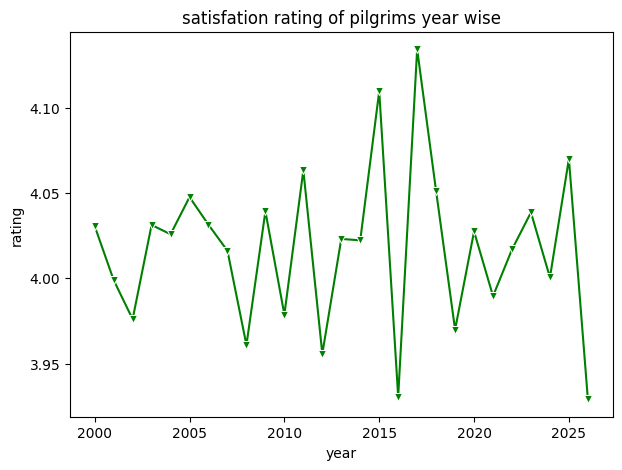

In [20]:
satisfaction_rating_average=df.groupby('year')['satisfaction_rating'].mean()
plt.figure(figsize=(7,5))
sns.lineplot(x=satisfaction_rating_average.index,y=satisfaction_rating_average.values,marker="v",color="green")
plt.title("satisfation rating of pilgrims year wise")
plt.xlabel("year")
plt.ylabel("rating")

**Is there correlation between columns of data?**

In [21]:
df.corr(numeric_only=True)

,year,total_pilgrims,male_percentage,female_percentage,average_age,average_travel_cost_usd,visa_approval_rate,flights_arranged,hotels_booked,satisfaction_rating,economic_impact_usd,count_male,count_female
year,1.000000,0.001660,0.021623,-0.021623,-0.004093,0.003607,-0.002652,-0.038924,0.032879,-0.001052,0.002441,0.006621,-0.004532
total_pilgrims,0.001660,1.000000,0.021944,-0.021944,0.014959,-0.004209,0.002880,-0.009426,-0.027553,0.011609,0.664939,0.978039,0.966691
male_percentage,0.021623,0.021944,1.000000,-1.000000,-0.036346,-0.011853,-0.020396,-0.012572,-0.020530,-0.016989,0.004886,0.203552,-0.202396
female_percentage,-0.021623,-0.021944,-1.000000,1.000000,0.036346,0.011853,0.020396,0.012572,0.020530,0.016989,-0.004886,-0.203552,0.202396
average_age,-0.004093,0.014959,-0.036346,0.036346,1.000000,-0.003101,0.021892,-0.020688,0.005091,0.022346,-0.007271,0.007566,0.023137
average_travel_cost_usd,0.003607,-0.004209,-0.011853,0.011853,-0.003101,1.000000,0.012452,-0.012436,0.035202,-0.020892,0.530536,-0.007872,0.000543
visa_approval_rate,-0.002652,0.002880,-0.020396,0.020396,0.021892,0.012452,1.000000,0.007769,-0.004323,-0.025565,-0.005751,-0.000726,0.007135
flights_arranged,-0.038924,-0.009426,-0.012572,0.012572,-0.020688,-0.012436,0.007769,1.000000,0.028049,-0.021165,-0.020352,-0.010894,-0.007054
hotels_booked,0.032879,-0.027553,-0.020530,0.020530,0.005091,0.035202,-0.004323,0.028049,1.000000,0.028512,-0.003122,-0.031536,-0.021002
satisfaction_rating,-0.001052,0.011609,-0.016989,0.016989,0.022346,-0.020892,-0.025565,-0.021165,0.028512,1.000000,0.009640,0.009106,0.013983


**Countries wise analysis**

In [22]:
country_wise_group=df.groupby('country')

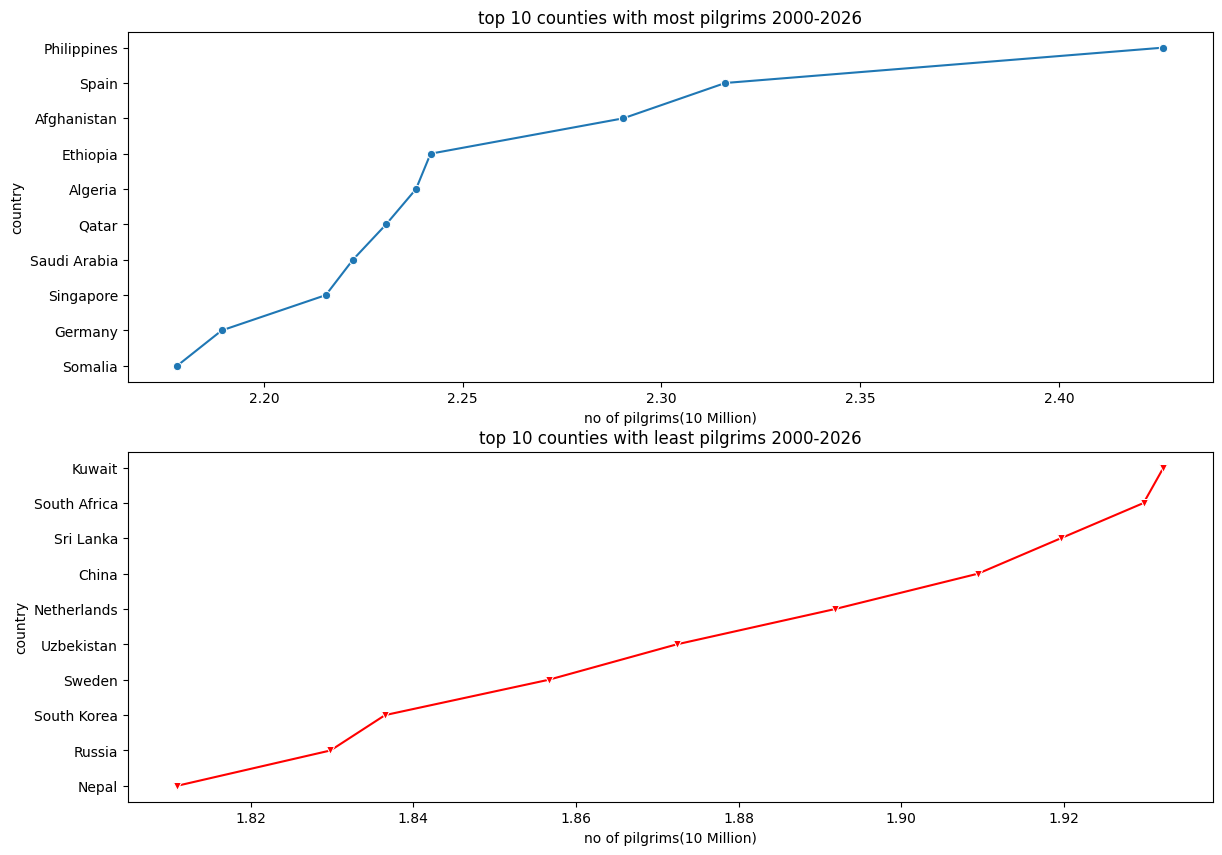

In [23]:
total_pilgrimage_country=country_wise_group['total_pilgrims'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
plt.title("top 10 counties with most pilgrims 2000-2026")
sns.lineplot(y=total_pilgrimage_country.head(10).index,x=total_pilgrimage_country.head(10).values/1e7,marker="o")
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.subplot(2,1,2)
plt.title("top 10 counties with least pilgrims 2000-2026")
sns.lineplot(y=total_pilgrimage_country.tail(10).index,x=total_pilgrimage_country.tail(10).values/1e7,marker="v",color="red")
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.show()

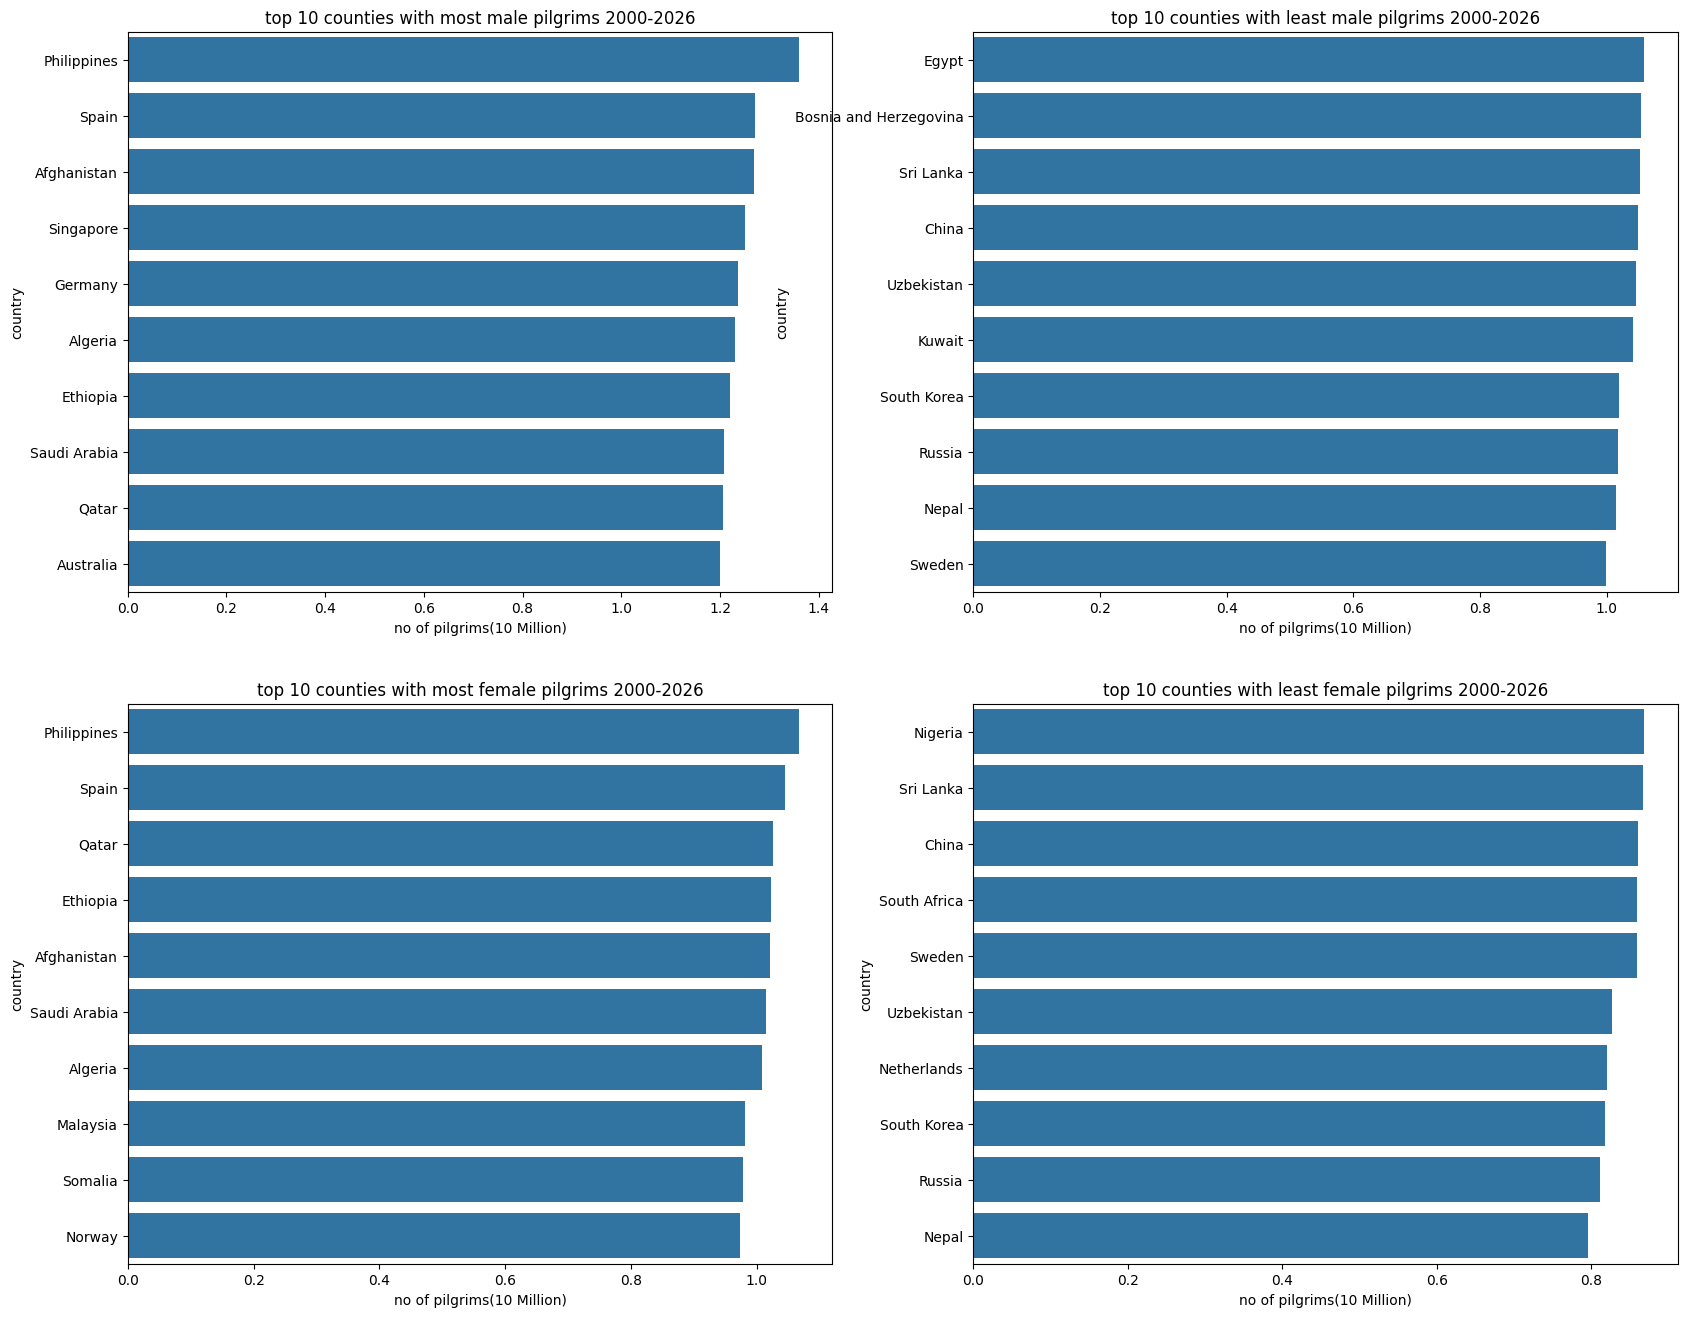

In [24]:
male_count_country=country_wise_group['count_male'].sum().sort_values(ascending=False)
female_count_country=country_wise_group['count_female'].sum().sort_values(ascending=False)
plt.figure(figsize=(20,16))
plt.subplot(2,2,1)
plt.title("top 10 counties with most male pilgrims 2000-2026")
sns.barplot(y=male_count_country.head(10).index,x=male_count_country.head(10).values/1e7)
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.subplot(2,2,2)
plt.title("top 10 counties with least male pilgrims 2000-2026")
sns.barplot(y=male_count_country.tail(10).index,x=male_count_country.tail(10).values/1e7)
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.subplot(2,2,3)
plt.title("top 10 counties with most female pilgrims 2000-2026")
sns.barplot(y=female_count_country.head(10).index,x=female_count_country.head(10).values/1e7)
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.subplot(2,2,4)
plt.title("top 10 counties with least female pilgrims 2000-2026")
sns.barplot(y=female_count_country.tail(10).index,x=female_count_country.tail(10).values/1e7)
plt.ylabel("country")
plt.xlabel("no of pilgrims(10 Million)")
plt.show()


Text(0, 0.5, 'country')

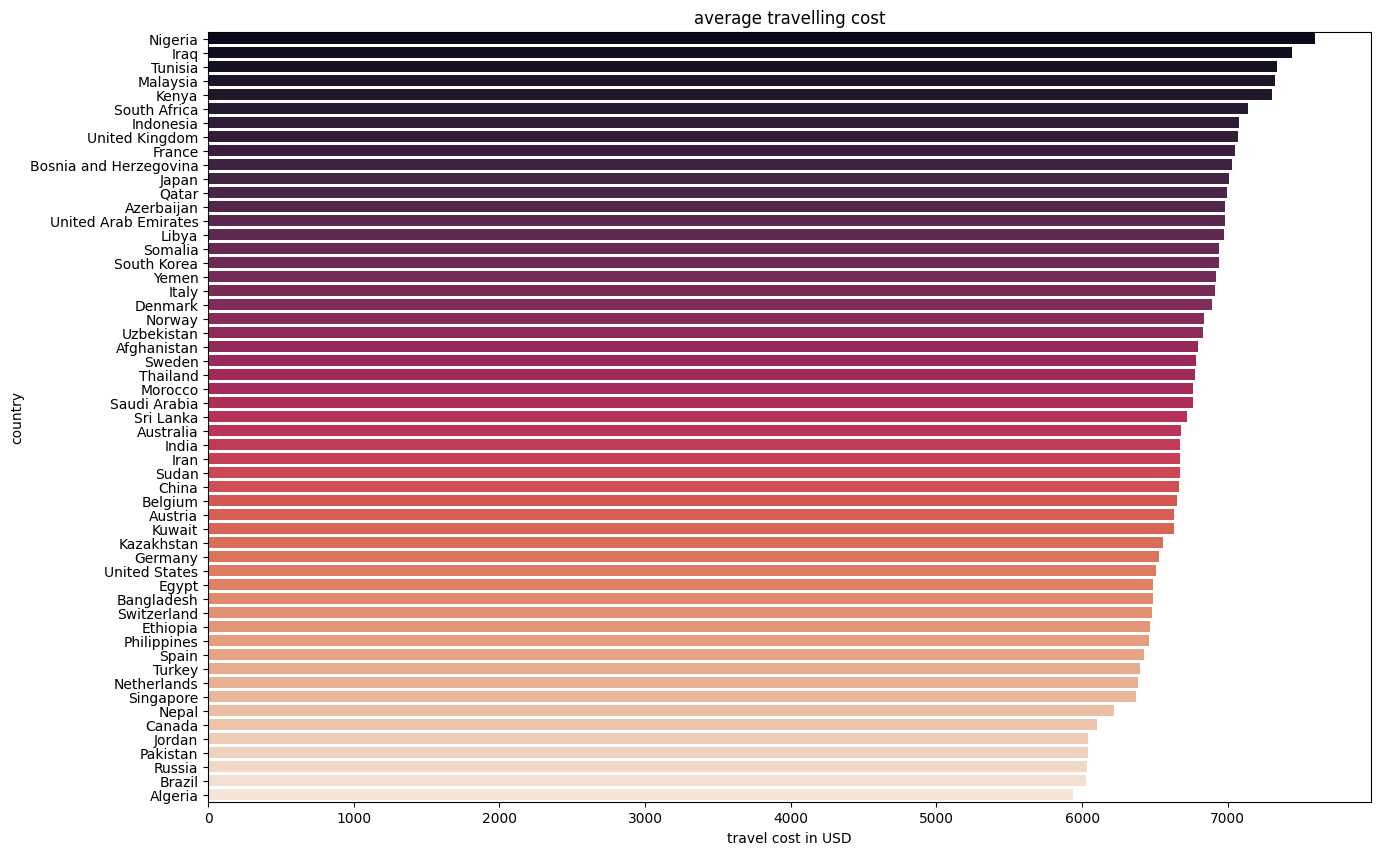

In [25]:
average_travel_cost_country=country_wise_group['average_travel_cost_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,10))
sns.barplot(y=average_travel_cost_country.index,x=average_travel_cost_country.values,palette="rocket")
plt.title("average travelling cost")
plt.xlabel("travel cost in USD")
plt.ylabel("country")

<Axes: title={'center': 'counties with least visa approval'}, xlabel='% approoval', ylabel='country'>

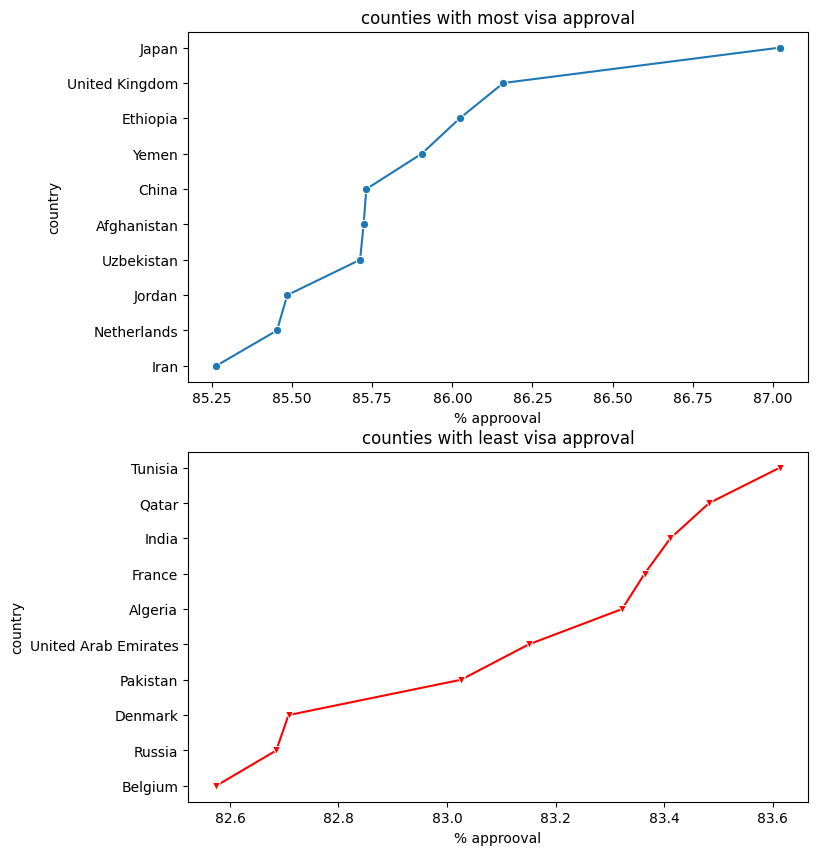

In [26]:
visa_approval_country=country_wise_group['visa_approval_rate'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
sns.lineplot(y=visa_approval_country.head(10).index,x=visa_approval_country.head(10).values,marker="o")
plt.title("counties with most visa approval")
plt.xlabel("% approoval")
plt.subplot(2,1,2)
plt.title("counties with least visa approval")
plt.xlabel("% approoval")
sns.lineplot(y=visa_approval_country.tail(10).index,x=visa_approval_country.tail(10).values,marker="v",color="red")



<Axes: title={'center': 'counties with least flight flied for pilgrims'}, xlabel='no of flights(thousand)', ylabel='country'>

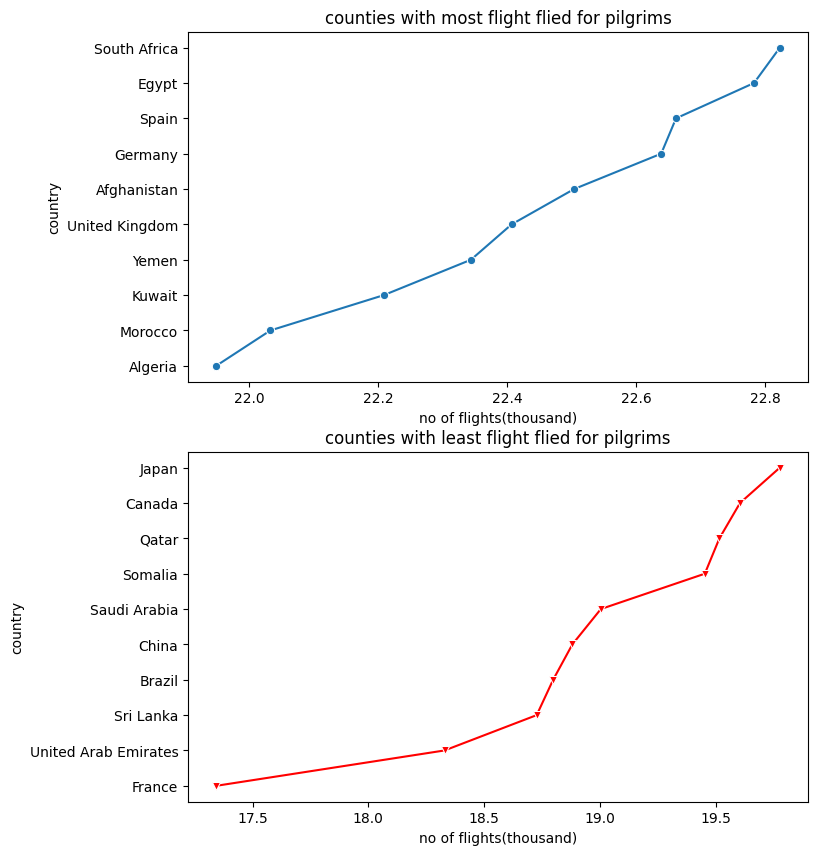

In [27]:
flight_count_country=country_wise_group['flights_arranged'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
sns.lineplot(y=flight_count_country.head(10).index,x=flight_count_country.head(10).values/1000,marker="o")
plt.title("counties with most flight flied for pilgrims")
plt.xlabel("no of flights(thousand)")
plt.subplot(2,1,2)
plt.title("counties with least flight flied for pilgrims")
plt.xlabel("no of flights(thousand)")
sns.lineplot(y=flight_count_country.tail(10).index,x=flight_count_country.tail(10).values/1000,marker="v",color="red")

<Axes: title={'center': 'counties with least satisfied pilgrims'}, xlabel='satisfaction rate out of 5', ylabel='country'>

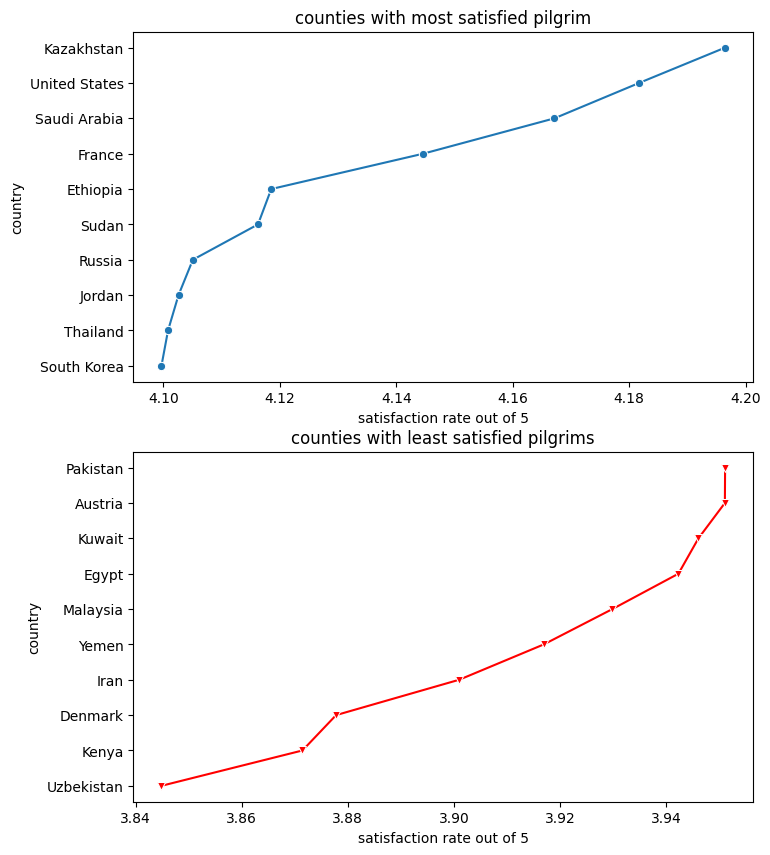

In [28]:
satisfaction_rate_country = (
    (df['satisfaction_rating'] * df['total_pilgrims'])
    .groupby(df['country'])
    .sum()
    /
    df.groupby('country')['total_pilgrims'].sum()
).sort_values(ascending=False)
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
sns.lineplot(y=satisfaction_rate_country.head(10).index,x=satisfaction_rate_country.head(10).values,marker="o")
plt.title("counties with most satisfied pilgrim")
plt.xlabel("satisfaction rate out of 5")
plt.subplot(2,1,2)
plt.title("counties with least satisfied pilgrims")
plt.xlabel("satisfaction rate out of 5")
sns.lineplot(y=satisfaction_rate_country.tail(10).index,x=satisfaction_rate_country.tail(10).values,marker="v",color="red")

<Axes: title={'center': 'counties with least economic impact 2000-2026'}, xlabel='economic impact in USD(Billion)', ylabel='country'>

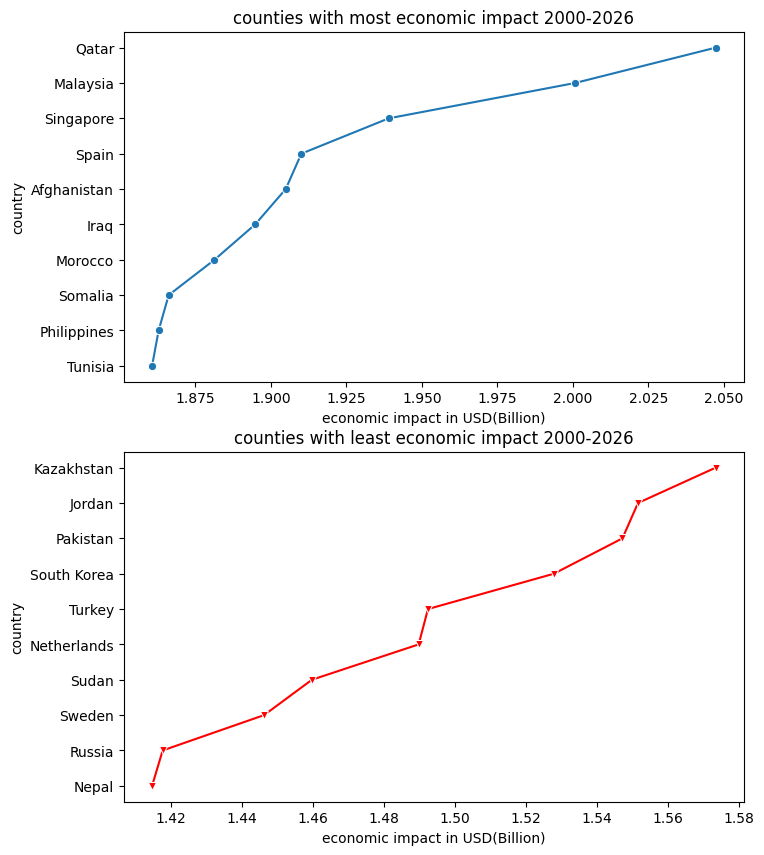

In [29]:
economic_impact_country=country_wise_group['economic_impact_usd'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
sns.lineplot(y=economic_impact_country.head(10).index,x=economic_impact_country.head(10).values/1e9,marker="o")
plt.title("counties with most economic impact 2000-2026")
plt.xlabel("economic impact in USD(Billion)")
plt.subplot(2,1,2)
plt.title("counties with least economic impact 2000-2026")
plt.xlabel("economic impact in USD(Billion)")
sns.lineplot(y=economic_impact_country.tail(10).index,x=economic_impact_country.tail(10).values/1e9,marker="v",color="red")

<Axes: title={'center': 'counties with least aged pilgrims 2000-2026'}, xlabel='age in years', ylabel='country'>

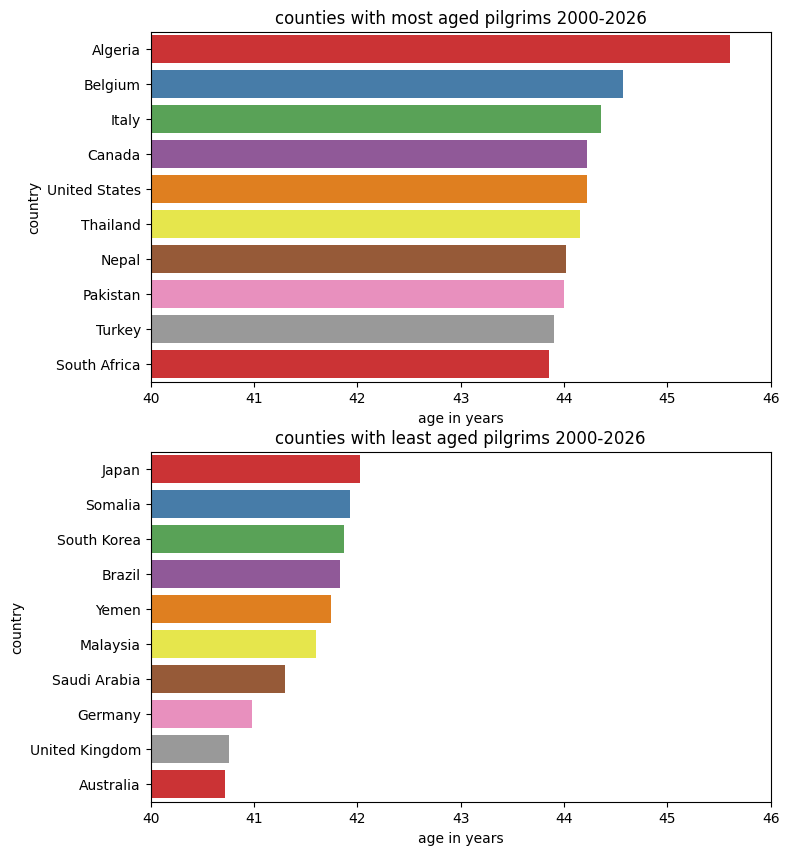

In [30]:
average_age_country = (
    (df['average_age'] * df['total_pilgrims'])
    .groupby(df['country'])
    .sum()
    /
    country_wise_group['total_pilgrims'].sum()
).sort_values(ascending=False)
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
sns.barplot(y=average_age_country.head(10).index,x=average_age_country.head(10).values,palette='Set1')
plt.title("counties with most aged pilgrims 2000-2026")
plt.xlim(40, 46)
plt.xlabel("age in years")
plt.subplot(2,1,2)
plt.title("counties with least aged pilgrims 2000-2026")
plt.xlabel("age in years")
plt.xlim(40, 46)
sns.barplot(y=average_age_country.tail(10).index,x=average_age_country.tail(10).values,palette='Set1')

**pilrimage type analysis**

In [31]:
pilgrimage_type_country=df.groupby('pilgrimage_type')

Text(0.5, 0, 'pilgrimage type')

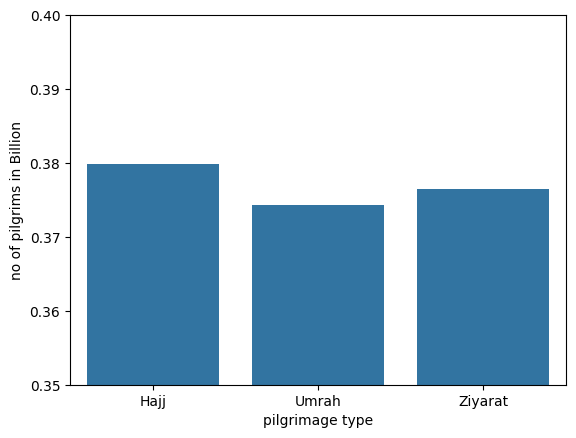

In [32]:
total_pilgrimage_type_pilty=pilgrimage_type_country['total_pilgrims'].sum()
sns.barplot(x=total_pilgrimage_type_pilty.index,y=total_pilgrimage_type_pilty.values/1e9)
plt.ylim(0.35,0.40)
plt.ylabel("no of pilgrims in Billion")
plt.xlabel("pilgrimage type")

<Axes: xlabel='total_pilgrims', ylabel='economic_impact_usd'>

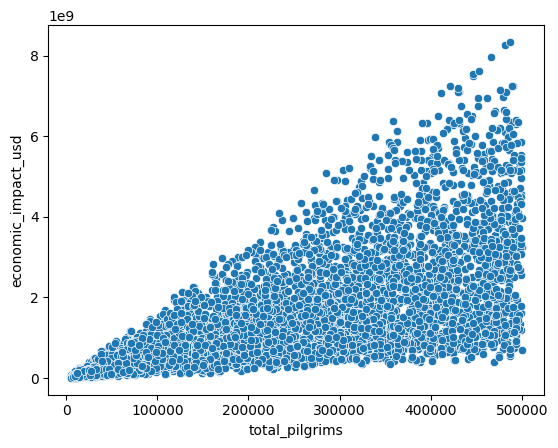

In [33]:
sns.scatterplot(
    data=df,
    x='total_pilgrims',
    y='economic_impact_usd'
)

<Axes: >

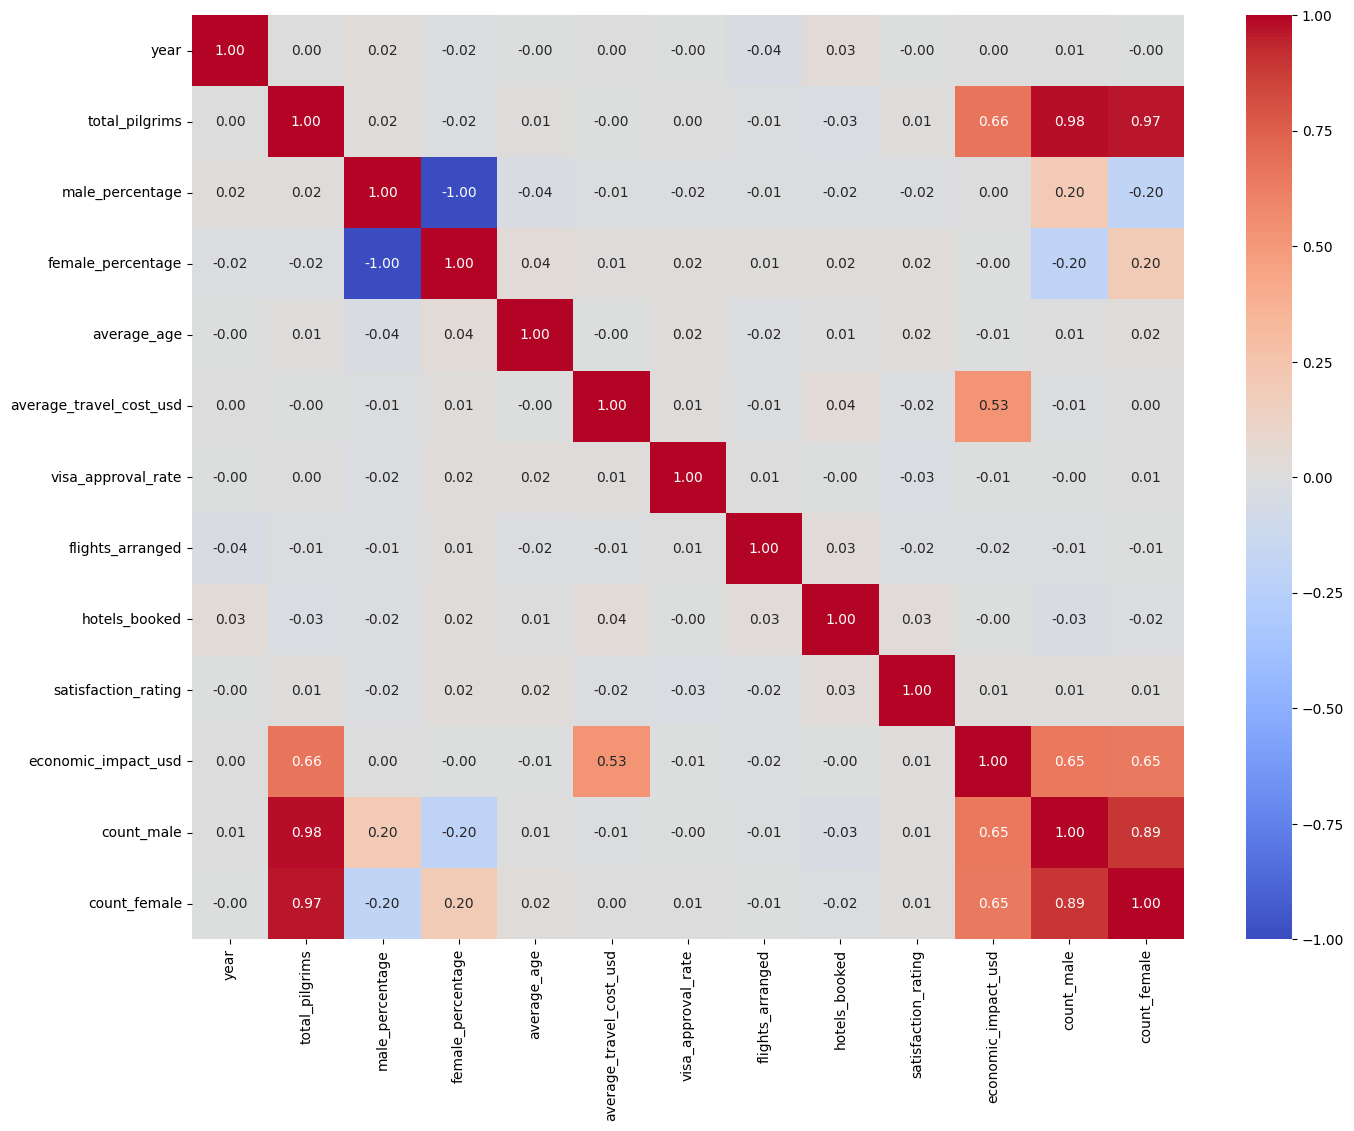

In [34]:
plt.figure(figsize=(16,12))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

**Conclusions**

____Key Findings____

....Pilgrim participation remained consistently high across the years, indicating sustained interest in Islamic pilgrimages throughout the study period.

...Economic impact showed a strong positive relationship with pilgrim volume, suggesting that increases in pilgrim numbers directly contribute to higher economic activity.

...Hotel bookings and flight arrangements closely followed pilgrim counts, highlighting the importance of transportation and accommodation infrastructure in supporting pilgrimage demand.

...The gender distribution of pilgrims remained relatively stable over time, with no major shifts observed across the study period.

...Average pilgrim age varied only moderately across countries, generally falling within a narrow range of approximately 41–46 years.

...Country-level differences were more pronounced in pilgrim volume, economic impact, and travel costs than in age or satisfaction ratings.

...Weighted and unweighted age calculations produced very similar results, indicating that age distributions are relatively stable across countries and pilgrim volumes.

...Satisfaction ratings showed limited variation across countries, suggesting a generally consistent pilgrimage experience among participants.

...Visa approval rates and travel costs varied across countries, which may influence accessibility and overall participation levels.

...Pilgrimage type significantly influenced total participation, demonstrating that different pilgrimage categories attract varying numbers of pilgrims